<a href="https://colab.research.google.com/github/beyzoskaya/estimating-biodiversity/blob/main/toy_llm_biodiversity_capitals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detailed tutorial: estimating unseen country–capital knowledge in a small LLM

This notebook is written as a **step-by-step teaching notebook**.

We use a small frozen instruction model:

```text
Qwen/Qwen2.5-0.5B-Instruct
```

We do **not** train or fine-tune it.

The complete experiment answers this question:

> After observing only some country–capital facts generated by the model, can we estimate how many additional correct facts remain unseen?

---

## Main idea

We create a very small factual universe:

```text
country → capital
```

Then we do two different experiments.

### Phase A — Direct probing

We directly ask:

```text
What is the capital of Palau?
```

This approximates which facts are accessible when the model receives a strong cue.

### Phase B — Free-choice sampling

We ask:

```text
Choose one country from this list and state its capital.
```

The model chooses which fact to reveal.

Repeated calls create a frequency distribution:

```text
France–Paris       20 observations
Japan–Tokyo        14 observations
Palau–Ngerulmud     1 observation
```

We then calculate:

- observed richness;
- singleton facts;
- doubleton facts;
- Chao1 total-richness estimate;
- Chao1 unseen-richness estimate;
- Good–Turing probability of seeing a new fact next.

Every calculation is shown manually.

# Ecological terminology translated to this experiment

| Ecological term | Meaning here |
|---|---|
| Species | One correct country–capital pair |
| Observation | One time the model generates that correct pair |
| Sample / survey | One independent model call |
| Species richness | Number of distinct correct pairs |
| Singleton | A correct pair observed exactly once |
| Doubleton | A correct pair observed exactly twice |
| Unseen species | Correct accessible pairs not yet observed |
| Sampling effort | Number of model calls |

Example:

```text
France–Paris appears 10 times.
Palau–Ngerulmud appears 1 time.
```

This means:

- there are 2 species;
- there are 11 observations;
- Palau–Ngerulmud is a singleton.

# Step 1 — Install packages

In Google Colab:

1. Open **Runtime → Change runtime type**.
2. Select a T4 GPU when available.
3. Run the following cell.

The notebook can run on CPU, but use fewer samples if it is slow.

In [1]:
!pip -q install -U "transformers>=4.45" accelerate pandas matplotlib
print("Packages installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 49.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
Packages installed.


# Step 2 — Import libraries and choose the model

Important settings:

- `MODEL_ID` selects the pretrained model.
- `device` uses a GPU when Colab provides one.
- random seeds make the experiment more reproducible.

In [2]:
import ast
import json
import random
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

print("Random seed:", SEED)
print("Selected model:", MODEL_ID)
print("Selected device:", device)
print("Selected numerical type:", dtype)

Random seed: 42
Selected model: Qwen/Qwen2.5-0.5B-Instruct
Selected device: cuda
Selected numerical type: torch.float16


# Step 3 — Define the small factual universe

We use only 12 country–capital facts.

The table has two purposes:

1. It tells us which answers are correct.
2. It defines a closed toy universe.

The table is **not** given to the model as training data.

In [3]:
GROUND_TRUTH = {
    "France": "Paris",
    "Japan": "Tokyo",
    "Türkiye": "Ankara",
    "Brazil": "Brasilia",
    "Canada": "Ottawa",
    "Australia": "Canberra",
    "Estonia": "Tallinn",
    "Mongolia": "Ulaanbaatar",
    "Suriname": "Paramaribo",
    "Palau": "Ngerulmud",
    "Comoros": "Moroni",
    "Micronesia": "Palikir",
}

# Country aliases are applied after accent- and case-normalization.
COUNTRY_ALIASES = {
    "turkey": "Türkiye",
    "turkiye": "Türkiye",
    "federated states of micronesia": "Micronesia",
    "micronesia": "Micronesia",
}

universe_df = pd.DataFrame(
    [
        {
            "fact_id": i + 1,
            "country": country,
            "capital": capital,
            "canonical_fact": f"{country} → {capital}",
        }
        for i, (country, capital) in enumerate(GROUND_TRUTH.items())
    ]
)

print("Number of possible facts in the reference universe:", len(universe_df))
print("\nReference universe:")
display(universe_df)

Number of possible facts in the reference universe: 12

Reference universe:


,fact_id,country,capital,canonical_fact
0,1,France,Paris,France → Paris
1,2,Japan,Tokyo,Japan → Tokyo
2,3,Türkiye,Ankara,Türkiye → Ankara
3,4,Brazil,Brasilia,Brazil → Brasilia
4,5,Canada,Ottawa,Canada → Ottawa
5,6,Australia,Canberra,Australia → Canberra
6,7,Estonia,Tallinn,Estonia → Tallinn
7,8,Mongolia,Ulaanbaatar,Mongolia → Ulaanbaatar
8,9,Suriname,Paramaribo,Suriname → Paramaribo
9,10,Palau,Ngerulmud,Palau → Ngerulmud


# Step 4 — Load the frozen pretrained model

The model is loaded with pretrained weights.

The following line:

```python
model.eval()
```

places the model in evaluation mode.

The model is never updated because:

- we do not create an optimizer;
- we do not calculate gradients;
- we use `torch.inference_mode()`.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
).to(device)

model.eval()

print("Model loaded successfully.")
print("Training mode active?", model.training)
print("False means that the model is in evaluation mode.")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully.
Training mode active? False
False means that the model is in evaluation mode.


# Step 5 — Create one function for model inference

This function:

1. formats a chat prompt;
2. converts the prompt to tokens;
3. runs the frozen model;
4. decodes only newly generated tokens;
5. returns the generated text.

In [5]:
def generate_one(
    prompt,
    *,
    do_sample=True,
    temperature=0.8,
    max_new_tokens=50,
):
    messages = [
        {
            "role": "system",
            "content": (
                "You are a factual assistant. "
                "Follow the requested output format exactly. "
                "Do not invent countries outside the supplied list."
            ),
        },
        {
            "role": "user",
            "content": prompt,
        },
    ]

    formatted_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    model_inputs = tokenizer(
        formatted_prompt,
        return_tensors="pt",
    ).to(device)

    generation_arguments = {
        **model_inputs,
        "max_new_tokens": max_new_tokens,
        "do_sample": do_sample,
        "pad_token_id": tokenizer.eos_token_id,
    }

    if do_sample:
        generation_arguments["temperature"] = temperature
        generation_arguments["top_p"] = 0.95

    with torch.inference_mode():
        generated = model.generate(**generation_arguments)

    generated_only = generated[
        0,
        model_inputs["input_ids"].shape[1]:,
    ]

    answer = tokenizer.decode(
        generated_only,
        skip_special_tokens=True,
    ).strip()

    return answer


print("Generation function is ready.")

Generation function is ready.


# Step 6 — Test one model call manually

Before running many samples, inspect one answer.

The model is asked directly about France.

In [6]:
test_prompt = """
What is the capital of France?

Return exactly:
{"country": "France", "capital": "CITY"}
"""

test_answer = generate_one(
    test_prompt,
    do_sample=False,
    max_new_tokens=30,
)

print("PROMPT")
print("------")
print(test_prompt)

print("\nRAW MODEL ANSWER")
print("----------------")
print(test_answer)

PROMPT
------

What is the capital of France?

Return exactly:
{"country": "France", "capital": "CITY"}


RAW MODEL ANSWER
----------------
The capital of France is Paris.


# Step 7 — Parse generated text into a country–capital pair

Models do not always return perfect JSON.

The parser tries:

1. JSON;
2. Python-dictionary syntax;
3. a fallback text pattern.

After parsing, a response becomes:

```python
("France", "Paris")
```

In [7]:
def remove_accents(value):
    """
    Remove diacritics for comparison.

    Examples:
        Brasília -> Brasilia
        İstanbul -> Istanbul
    """
    if value is None:
        return None

    normalized = unicodedata.normalize(
        "NFKD",
        str(value),
    )

    return "".join(
        character
        for character in normalized
        if not unicodedata.combining(character)
    )


def clean_generated_value(value):
    """
    Remove common model formatting while preserving readable text.
    """
    if value is None:
        return None

    value = str(value).strip()
    value = value.replace("```json", "")
    value = value.replace("```python", "")
    value = value.replace("```", "")
    value = value.strip()
    value = value.strip('"').strip("'")
    value = value.rstrip(".,;:")

    return " ".join(value.split())


def normalize_for_comparison(value):
    """
    Create a stable comparison form:
    lowercase, accent-free, and whitespace-normalized.
    """
    value = clean_generated_value(value)

    if value is None:
        return None

    value = remove_accents(value)

    return value.casefold()


COUNTRY_LOOKUP = {
    normalize_for_comparison(country): country
    for country in GROUND_TRUTH
}


def normalize_country(value):
    if value is None:
        return None

    comparison_value = normalize_for_comparison(value)

    if comparison_value in COUNTRY_ALIASES:
        return COUNTRY_ALIASES[comparison_value]

    if comparison_value in COUNTRY_LOOKUP:
        return COUNTRY_LOOKUP[comparison_value]

    # Keep an outside-universe country readable for diagnostics.
    return clean_generated_value(value)


def normalize_capital(value):
    return clean_generated_value(value)


def parse_pair(text, expected_country=None):
    """
    Parse several possible answer formats.

    Supported examples:
        {"country": "France", "capital": "Paris"}
        {'country': 'France', 'capital': 'Paris'}
        Country: France, Capital: Paris
        The capital of France is Paris.
        France's capital is Paris.
        Paris

    For direct probing, pass expected_country so a one-word answer such as
    'Paris' can still be associated with the known queried country.
    """
    if text is None:
        return None, None

    cleaned_text = str(text).strip()

    if not cleaned_text:
        return None, None

    # Attempt 1: JSON or Python dictionary.
    dictionary_matches = re.findall(
        r"\{[^{}]*\}",
        cleaned_text,
        flags=re.DOTALL,
    )

    for candidate in dictionary_matches:
        for parser in (json.loads, ast.literal_eval):
            try:
                parsed = parser(candidate)

                if not isinstance(parsed, dict):
                    continue

                normalized_keys = {
                    str(key).strip().casefold(): value
                    for key, value in parsed.items()
                }

                country = normalized_keys.get("country")
                capital = normalized_keys.get("capital")

                if country is not None and capital is not None:
                    return (
                        normalize_country(country),
                        normalize_capital(capital),
                    )

            except (json.JSONDecodeError, ValueError, SyntaxError, TypeError):
                continue

    # Attempt 2: labeled text, country first.
    country_first = re.search(
        r"\bcountry\b\s*[:=\-]\s*[\"']?([^,\"';\n}]+)[\"']?"
        r".*?"
        r"\bcapital\b\s*[:=\-]\s*[\"']?([^,\"';\n}]+)[\"']?",
        cleaned_text,
        flags=re.IGNORECASE | re.DOTALL,
    )

    if country_first:
        return (
            normalize_country(country_first.group(1)),
            normalize_capital(country_first.group(2)),
        )

    # Attempt 3: labeled text, capital first.
    capital_first = re.search(
        r"\bcapital\b\s*[:=\-]\s*[\"']?([^,\"';\n}]+)[\"']?"
        r".*?"
        r"\bcountry\b\s*[:=\-]\s*[\"']?([^,\"';\n}]+)[\"']?",
        cleaned_text,
        flags=re.IGNORECASE | re.DOTALL,
    )

    if capital_first:
        return (
            normalize_country(capital_first.group(2)),
            normalize_capital(capital_first.group(1)),
        )

    # Attempt 4: natural-language statements.
    natural_patterns = [
        (
            r"\bthe\s+capital\s+of\s+(.+?)\s+is\s+"
            r"([A-Za-zÀ-ÿ .'\-]+?)(?:[.!?\n]|$)"
        ),
        (
            r"\b(.+?)(?:'s|’s)\s+capital\s+is\s+"
            r"([A-Za-zÀ-ÿ .'\-]+?)(?:[.!?\n]|$)"
        ),
        (
            r"\bcapital\s+city\s+of\s+(.+?)\s+is\s+"
            r"([A-Za-zÀ-ÿ .'\-]+?)(?:[.!?\n]|$)"
        ),
    ]

    for pattern in natural_patterns:
        match = re.search(
            pattern,
            cleaned_text,
            flags=re.IGNORECASE,
        )

        if match:
            return (
                normalize_country(match.group(1)),
                normalize_capital(match.group(2)),
            )

    # Attempt 5: direct-question fallback.
    if expected_country is not None:
        candidate_capital = cleaned_text

        candidate_capital = re.sub(
            r"^(the\s+capital\s+is|capital\s*[:=\-])\s*",
            "",
            candidate_capital,
            flags=re.IGNORECASE,
        )

        candidate_capital = clean_generated_value(candidate_capital)

        if (
            candidate_capital
            and "\n" not in candidate_capital
            and len(candidate_capital.split()) <= 6
        ):
            return (
                normalize_country(expected_country),
                candidate_capital,
            )

    return None, None


parsed_country, parsed_capital = parse_pair(
    test_answer,
    expected_country="France",
)

print("RAW ANSWER:")
print(repr(test_answer))
print("Parsed country:", parsed_country)
print("Parsed capital:", parsed_capital)

RAW ANSWER:
'The capital of France is Paris.'
Parsed country: France
Parsed capital: Paris


# Step 8 — Check whether a parsed answer is correct

A generated pair is valid when:

1. the country belongs to our 12-country universe;
2. the generated capital equals the reference capital.

Example:

```text
France → Paris
```

is valid.

Example:

```text
France → Lyon
```

is invalid.

In [8]:
def classify_pair(country, capital):
    """
    Classify a generated pair into one of four categories.
    """
    if country is None or capital is None:
        return "unparsable"

    if country not in GROUND_TRUTH:
        return "outside_universe"

    gold_capital = GROUND_TRUTH[country]

    if (
        normalize_for_comparison(capital)
        ==
        normalize_for_comparison(gold_capital)
    ):
        return "valid"

    return "wrong_capital"


def evaluate_pair(country, capital):
    return classify_pair(country, capital) == "valid"


test_status = classify_pair(
    parsed_country,
    parsed_capital,
)

print("Generated pair:", (parsed_country, parsed_capital))
print("Expected capital:", GROUND_TRUTH.get(parsed_country))
print("Status:", test_status)
print("Is the answer correct?", test_status == "valid")

Generated pair: ('France', 'Paris')
Expected capital: Paris
Status: valid
Is the answer correct? True


# Phase A — Direct probing of every country

We now ask directly about all 12 countries.

For every country:

- use 3 prompt templates;
- repeat each template 3 times.

Therefore, the total number of direct-probing calls is:

\[
12 \times 3 \times 3 = 108.
\]

A fact is called **empirically accessible** if the correct answer appears at least once among its 9 attempts.

In [9]:
DIRECT_TEMPLATES = [
    (
        'What is the capital of {country}? '
        'Return JSON: {{"country": "{country}", "capital": "CITY"}}'
    ),
    (
        'Complete this fact: the capital city of {country} is what? '
        'Return JSON only with keys country and capital.'
    ),
    (
        'Name the current capital of {country}. '
        'Output exactly one JSON object with country and capital.'
    ),
]

DIRECT_REPEATS = 3

expected_direct_calls = (
    len(GROUND_TRUTH)
    * len(DIRECT_TEMPLATES)
    * DIRECT_REPEATS
)

print("Countries:", len(GROUND_TRUTH))
print("Templates per country:", len(DIRECT_TEMPLATES))
print("Repeats per template:", DIRECT_REPEATS)
print("Expected direct-probing calls:", expected_direct_calls)

Countries: 12
Templates per country: 3
Repeats per template: 3
Expected direct-probing calls: 108


## Step 9 — Run direct probing

This cell prints progress country by country.

In [10]:
direct_rows = []

for country_index, (country, gold_capital) in enumerate(
    GROUND_TRUTH.items(),
    start=1,
):
    print(
        f"Probing country {country_index}/{len(GROUND_TRUTH)}: "
        f"{country}"
    )

    for template_id, template in enumerate(DIRECT_TEMPLATES):
        for repeat in range(DIRECT_REPEATS):
            prompt = template.format(country=country)

            raw_answer = generate_one(
                prompt,
                do_sample=True,
                temperature=0.5,
                max_new_tokens=40,
            )

            parsed_country, parsed_capital = parse_pair(
                raw_answer,
                expected_country=country,
            )

            # Because this is a direct query, the intended country is known.
            is_correct = (
                parsed_capital is not None
                and parsed_capital.casefold()
                == gold_capital.casefold()
            )

            direct_rows.append(
                {
                    "country": country,
                    "gold_capital": gold_capital,
                    "template_id": template_id,
                    "repeat": repeat,
                    "raw_output": raw_answer,
                    "parsed_country": parsed_country,
                    "parsed_capital": parsed_capital,
                    "is_correct": is_correct,
                }
            )

direct_df = pd.DataFrame(direct_rows)

print("\nDirect probing finished.")
print("Actual number of rows:", len(direct_df))

Probing country 1/12: France
Probing country 2/12: Japan
Probing country 3/12: Türkiye
Probing country 4/12: Brazil
Probing country 5/12: Canada
Probing country 6/12: Australia
Probing country 7/12: Estonia
Probing country 8/12: Mongolia
Probing country 9/12: Suriname
Probing country 10/12: Palau
Probing country 11/12: Comoros
Probing country 12/12: Micronesia

Direct probing finished.
Actual number of rows: 108


## Step 10 — Inspect the direct-probing responses

Look at the raw text and the parsed result.

In [11]:
display_columns = [
    "country",
    "gold_capital",
    "template_id",
    "repeat",
    "raw_output",
    "parsed_capital",
    "is_correct",
]

print("First 20 direct-probing attempts:")
display(direct_df[display_columns].head(20))

First 20 direct-probing attempts:


,country,gold_capital,template_id,repeat,raw_output,parsed_capital,is_correct
0,France,Paris,0,0,"{""country"": ""France"", ""capital"": ""Paris""}",Paris,True
1,France,Paris,0,1,"{""country"": ""France"", ""capital"": ""Paris""}",Paris,True
2,France,Paris,0,2,"{""country"": ""France"", ""capital"": ""Paris""}",Paris,True
3,France,Paris,1,0,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
4,France,Paris,1,1,"```json\n{\n ""country"": ""France"",\n ""capital...",Paris,True
5,France,Paris,1,2,"```json\n{\n ""country"": ""France"",\n ""capital...",Paris,True
6,France,Paris,2,0,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
7,France,Paris,2,1,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
8,France,Paris,2,2,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",Paris,True
9,Japan,Tokyo,0,0,"{""country"": ""Japan"", ""capital"": ""Tokyo""}",Tokyo,True


## Step 11 — Calculate fact-level accessibility

For each country, calculate:

$
\text{detection rate}
=
\frac{\text{correct attempts}}
{\text{total attempts}}
$

A fact is marked accessible when:

$
\text{correct attempts} > 0.
$

In [12]:
accessibility = (
    direct_df
    .groupby(
        ["country", "gold_capital"],
        as_index=False,
    )
    .agg(
        correct_attempts=("is_correct", "sum"),
        total_attempts=("is_correct", "size"),
    )
)

accessibility["detection_rate"] = (
    accessibility["correct_attempts"]
    / accessibility["total_attempts"]
)

accessibility["accessible"] = (
    accessibility["correct_attempts"] > 0
)

ACCESSIBLE_FACTS = {
    (row.country, row.gold_capital)
    for row in accessibility.itertuples()
    if row.accessible
}

S_ACCESSIBLE = len(ACCESSIBLE_FACTS)

print("Accessibility results:")
display(
    accessibility.sort_values(
        ["accessible", "detection_rate"],
        ascending=[False, False],
    )
)

print("\nREFERENCE UNIVERSE SIZE")
print("-----------------------")
print(len(GROUND_TRUTH))

print("\nEMPIRICALLY ACCESSIBLE RICHNESS")
print("--------------------------------")
print(S_ACCESSIBLE)

print(
    "\nInterpretation: the model produced the correct answer "
    "at least once for this many country–capital facts."
)

Accessibility results:


,country,gold_capital,correct_attempts,total_attempts,detection_rate,accessible
0,Australia,Canberra,9,9,1.000000,True
2,Canada,Ottawa,9,9,1.000000,True
5,France,Paris,9,9,1.000000,True
6,Japan,Tokyo,9,9,1.000000,True
4,Estonia,Tallinn,8,9,0.888889,True
8,Mongolia,Ulaanbaatar,7,9,0.777778,True
3,Comoros,Moroni,4,9,0.444444,True
7,Micronesia,Palikir,4,9,0.444444,True
11,Türkiye,Ankara,4,9,0.444444,True
10,Suriname,Paramaribo,3,9,0.333333,True



REFERENCE UNIVERSE SIZE
-----------------------
12

EMPIRICALLY ACCESSIBLE RICHNESS
--------------------------------
11

Interpretation: the model produced the correct answer at least once for this many country–capital facts.


# Phase B — Free-choice biodiversity sampling

Now we stop asking about each country directly.

Instead, every call gives the model the entire list and asks it to choose one country.

The model may prefer familiar countries.

Example frequency distribution:

```text
France–Paris       20
Japan–Tokyo        15
Palau–Ngerulmud     1
```

This is the abundance data used by Chao1 and Good–Turing.

## Step 12 — Define the free-choice prompt

In [13]:
ALLOWED_COUNTRIES = list(GROUND_TRUTH)

FREE_PROMPT = f"""
You must choose exactly one country from the allowed list below.

Allowed countries:
{json.dumps(ALLOWED_COUNTRIES, ensure_ascii=False)}

Do not use any country outside this list.

Return exactly one JSON object and no other text:

{{"country": "<one exact country name copied from the list>",
  "capital": "<capital city>"}}
"""

print(FREE_PROMPT)


You must choose exactly one country from the allowed list below.

Allowed countries:
["France", "Japan", "Türkiye", "Brazil", "Canada", "Australia", "Estonia", "Mongolia", "Suriname", "Palau", "Comoros", "Micronesia"]

Do not use any country outside this list.

Return exactly one JSON object and no other text:

{"country": "<one exact country name copied from the list>",
  "capital": "<capital city>"}



## Step 13 — Run repeated free-choice inference

For a first CPU test, use:

```python
N_SAMPLES = 30
```

For a better GPU experiment, use:

```python
N_SAMPLES = 120
```

Each model call is one sampling unit.

In [14]:
N_SAMPLES = 60

print("Number of planned sampling units:", N_SAMPLES)
print("One model call = one sampling unit.")

Number of planned sampling units: 60
One model call = one sampling unit.


In [15]:
sample_rows = []

for sample_id in range(N_SAMPLES):
    raw_answer = generate_one(
        FREE_PROMPT,
        do_sample=True,
        temperature=0.7,
        max_new_tokens=45,
    )

    country, capital = parse_pair(raw_answer)

    status = classify_pair(
        country,
        capital,
    )

    is_valid_fact = status == "valid"

    if is_valid_fact:
        canonical_fact = (
            country,
            GROUND_TRUTH[country],
        )
    else:
        canonical_fact = None

    sample_rows.append(
        {
            "sample_id": sample_id + 1,
            "raw_output": raw_answer,
            "country": country,
            "capital": capital,
            "status": status,
            "is_valid_fact": is_valid_fact,
            "canonical_fact": canonical_fact,
        }
    )

    if (sample_id + 1) % 10 == 0:
        print(
            f"Completed {sample_id + 1}/{N_SAMPLES} "
            "free-choice samples."
        )

samples_df = pd.DataFrame(sample_rows)

print("\nFree-choice sampling finished.")

Completed 10/60 free-choice samples.
Completed 20/60 free-choice samples.
Completed 30/60 free-choice samples.
Completed 40/60 free-choice samples.
Completed 50/60 free-choice samples.
Completed 60/60 free-choice samples.

Free-choice sampling finished.


## Step 14 — Inspect every free-choice answer

This table shows:

- raw response;
- parsed country and capital;
- classification status;
- whether the pair is a valid target fact;
- canonical species identifier.

`canonical_fact = None` is correct for:

- wrong capitals;
- countries outside the defined universe;
- unparsable outputs.

A wrong output must never be silently converted into the correct canonical fact.

In [16]:
print(
    "Important: canonical_fact is intentionally None whenever "
    "status is not 'valid'."
)

display(
    samples_df[
        [
            "sample_id",
            "raw_output",
            "country",
            "capital",
            "status",
            "is_valid_fact",
            "canonical_fact",
        ]
    ]
)

Important: canonical_fact is intentionally None whenever status is not 'valid'.


,sample_id,raw_output,country,capital,status,is_valid_fact,canonical_fact
0,1,"{\n ""country"": ""Japan"",\n ""capital"": ""Tokyo""\n}",Japan,Tokyo,valid,True,"(Japan, Tokyo)"
1,2,"{\n ""country"": ""Australia"",\n ""capital"": ""Ca...",Australia,Canberra,valid,True,"(Australia, Canberra)"
2,3,"{\n ""country"": ""France"",\n ""capital"": ""Paris...",France,Paris,valid,True,"(France, Paris)"
3,4,"{\n ""country"": ""Australia"",\n ""capital"": ""Ca...",Australia,Canberra,valid,True,"(Australia, Canberra)"
4,5,"{\n ""country"": ""Turkey"",\n ""capital"": "" Anka...",Türkiye,Ankara,valid,True,"(Türkiye, Ankara)"
5,6,"{\n ""country"": ""Turkey"",\n ""capital"": ""Tehra...",Türkiye,Tehran,wrong_capital,False,None
6,7,"{\n ""country"": ""Canada"",\n ""capital"": ""Ottaw...",Canada,Ottawa,valid,True,"(Canada, Ottawa)"
7,8,"{""country"": ""Japan"", ""capital"": ""Tokyo""}",Japan,Tokyo,valid,True,"(Japan, Tokyo)"
8,9,"{""country"": ""Canada"", ""capital"": ""Ottawa""}",Canada,Ottawa,valid,True,"(Canada, Ottawa)"
9,10,"{\n ""country"": ""Turkey"",\n ""capital"": "" Anka...",Türkiye,Ankara,valid,True,"(Türkiye, Ankara)"


### Diagnostic examples

These examples illustrate why some rows remain non-canonical:

- `Australia → Perth` → `wrong_capital`
- `China → Beijing` → `outside_universe`
- `Brazil → Brasília` → `valid` after accent-insensitive comparison
- malformed text with no reliable pair → `unparsable`

In [17]:
diagnostic_examples = [
    ("Australia", "Perth"),
    ("China", "Beijing"),
    ("Brazil", "Brasília"),
    (None, None),
]

for country, capital in diagnostic_examples:
    print(
        (country, capital),
        "->",
        classify_pair(country, capital),
    )

('Australia', 'Perth') -> wrong_capital
('China', 'Beijing') -> outside_universe
('Brazil', 'Brasília') -> valid
(None, None) -> unparsable


## Step 15 — Count valid and invalid observations

In [18]:
number_valid = int(
    samples_df["is_valid_fact"].sum()
)

number_invalid = int(
    (~samples_df["is_valid_fact"]).sum()
)

print("Total model calls:", len(samples_df))
print("Valid correct fact observations:", number_valid)
print("All non-valid observations:", number_invalid)

print("\nStatus counts:")
display(
    samples_df["status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="count")
)

print("\nStatus meanings:")
print("- valid: correct pair inside the toy universe")
print("- wrong_capital: country is in the universe, capital is wrong")
print("- outside_universe: pair uses a country outside the toy universe")
print("- unparsable: response could not be reliably parsed")

print(
    "\nOnly rows with status='valid' are used in the "
    "main biodiversity calculation."
)

Total model calls: 60
Valid correct fact observations: 57
All non-valid observations: 3

Status counts:


,status,count
0,valid,57
1,wrong_capital,3



Status meanings:
- valid: correct pair inside the toy universe
- wrong_capital: country is in the universe, capital is wrong
- outside_universe: pair uses a country outside the toy universe
- unparsable: response could not be reliably parsed

Only rows with status='valid' are used in the main biodiversity calculation.


## Step 16 — Build the abundance table

Suppose the valid outputs are:

```text
France–Paris
Japan–Tokyo
France–Paris
Palau–Ngerulmud
France–Paris
```

Then the abundance counts are:

```text
France–Paris        3
Japan–Tokyo         1
Palau–Ngerulmud     1
```

The number of distinct species is 3.

In [19]:
valid_facts = (
    samples_df
    .loc[
        samples_df["is_valid_fact"],
        "canonical_fact",
    ]
    .tolist()
)

fact_counts = Counter(valid_facts)

frequency_rows = []

for fact, count in fact_counts.items():
    country, capital = fact

    frequency_rows.append(
        {
            "country": country,
            "capital": capital,
            "canonical_fact": f"{country} → {capital}",
            "frequency": count,
            "is_singleton": count == 1,
            "is_doubleton": count == 2,
            "accessible_in_phase_A":
                fact in ACCESSIBLE_FACTS,
        }
    )

frequency_df = pd.DataFrame(
    frequency_rows
).sort_values(
    ["frequency", "country"],
    ascending=[False, True],
)

print("Abundance table:")
display(frequency_df)

print("\nRaw Counter object:")
print(fact_counts)

Abundance table:


,country,capital,canonical_fact,frequency,is_singleton,is_doubleton,accessible_in_phase_A
1,Australia,Canberra,Australia → Canberra,14,False,False,True
0,Japan,Tokyo,Japan → Tokyo,14,False,False,True
2,France,Paris,France → Paris,13,False,False,True
3,Türkiye,Ankara,Türkiye → Ankara,8,False,False,True
4,Canada,Ottawa,Canada → Ottawa,7,False,False,True
5,Brazil,Brasilia,Brazil → Brasilia,1,True,False,False



Raw Counter object:
Counter({('Japan', 'Tokyo'): 14, ('Australia', 'Canberra'): 14, ('France', 'Paris'): 13, ('Türkiye', 'Ankara'): 8, ('Canada', 'Ottawa'): 7, ('Brazil', 'Brasilia'): 1})


# Step 17 — Calculate the four required numbers

We need:

## 1. Total valid observations: \(n\)

Add all frequencies.

## 2. Observed richness: \(S_{\text{obs}}\)

Count how many different correct facts appear.

## 3. Singleton count: \(f_1\)

Count facts whose frequency equals 1.

## 4. Doubleton count: \(f_2\)

Count facts whose frequency equals 2.

In [20]:
n = sum(fact_counts.values())

S_obs = len(fact_counts)

f1 = sum(
    frequency == 1
    for frequency in fact_counts.values()
)

f2 = sum(
    frequency == 2
    for frequency in fact_counts.values()
)

print("CALCULATION INPUTS")
print("==================")

print("\n1. n = total number of valid observations")
print("   Frequencies:", list(fact_counts.values()))
print("   Sum of frequencies =", n)

print("\n2. S_obs = number of distinct observed facts")
print("   Distinct fact keys:")
for fact in fact_counts:
    print("  ", fact)
print("   Number of distinct facts =", S_obs)

print("\n3. f1 = number of singleton facts")
singleton_facts = [
    fact
    for fact, frequency in fact_counts.items()
    if frequency == 1
]
for fact in singleton_facts:
    print("  singleton:", fact)
print("   f1 =", f1)

print("\n4. f2 = number of doubleton facts")
doubleton_facts = [
    fact
    for fact, frequency in fact_counts.items()
    if frequency == 2
]
for fact in doubleton_facts:
    print("  doubleton:", fact)
print("   f2 =", f2)

CALCULATION INPUTS

1. n = total number of valid observations
   Frequencies: [14, 14, 13, 8, 7, 1]
   Sum of frequencies = 57

2. S_obs = number of distinct observed facts
   Distinct fact keys:
   ('Japan', 'Tokyo')
   ('Australia', 'Canberra')
   ('France', 'Paris')
   ('Türkiye', 'Ankara')
   ('Canada', 'Ottawa')
   ('Brazil', 'Brasilia')
   Number of distinct facts = 6

3. f1 = number of singleton facts
  singleton: ('Brazil', 'Brasilia')
   f1 = 1

4. f2 = number of doubleton facts
   f2 = 0


# Step 18 — Manually calculate Chao1

We use the bias-corrected form:

$
\widehat S_{\text{Chao1}}
=
S_{\text{obs}}
+
\frac{f_1(f_1-1)}
{2(f_2+1)}
$

It has two parts.

## Part A — Already observed richness

$
S_{\text{obs}}
$

## Part B — Estimated missing richness

$
\frac{f_1(f_1-1)}
{2(f_2+1)}
$

Therefore:

$
\text{estimated unseen richness}
=
\widehat S_{\text{Chao1}}
-
S_{\text{obs}}
$

In [21]:
chao_correction_numerator = f1 * (f1 - 1)

chao_correction_denominator = 2 * (f2 + 1)

estimated_unseen_chao1 = (
    chao_correction_numerator
    / chao_correction_denominator
)

S_chao1 = (
    S_obs
    + estimated_unseen_chao1
)

print("CHAO1 MANUAL CALCULATION")
print("========================")

print("\nFormula:")
print(
    "S_Chao1 = S_obs + "
    "[f1 × (f1 - 1)] / [2 × (f2 + 1)]"
)

print("\nSubstitute the observed values:")
print(
    f"S_Chao1 = {S_obs} + "
    f"[{f1} × ({f1} - 1)] / "
    f"[2 × ({f2} + 1)]"
)

print("\nCalculate the numerator:")
print(
    f"{f1} × ({f1} - 1) "
    f"= {chao_correction_numerator}"
)

print("\nCalculate the denominator:")
print(
    f"2 × ({f2} + 1) "
    f"= {chao_correction_denominator}"
)

print("\nCalculate estimated unseen richness:")
print(
    f"{chao_correction_numerator} / "
    f"{chao_correction_denominator} "
    f"= {estimated_unseen_chao1:.3f}"
)

print("\nCalculate estimated total richness:")
print(
    f"{S_obs} + {estimated_unseen_chao1:.3f} "
    f"= {S_chao1:.3f}"
)

print("\nFINAL CHAO1 RESULTS")
print("-------------------")
print("Observed richness:", S_obs)
print(
    "Estimated unseen richness:",
    round(estimated_unseen_chao1, 3),
)
print(
    "Estimated total richness:",
    round(S_chao1, 3),
)

CHAO1 MANUAL CALCULATION

Formula:
S_Chao1 = S_obs + [f1 × (f1 - 1)] / [2 × (f2 + 1)]

Substitute the observed values:
S_Chao1 = 6 + [1 × (1 - 1)] / [2 × (0 + 1)]

Calculate the numerator:
1 × (1 - 1) = 0

Calculate the denominator:
2 × (0 + 1) = 2

Calculate estimated unseen richness:
0 / 2 = 0.000

Calculate estimated total richness:
6 + 0.000 = 6.000

FINAL CHAO1 RESULTS
-------------------
Observed richness: 6
Estimated unseen richness: 0.0
Estimated total richness: 6.0


# Step 19 — Manually calculate Good–Turing unseen probability

The simplest Good–Turing unseen-mass estimate is:

$
\widehat P_0
=
\frac{f_1}{n}
$

where:

- \(f_1\) is the number of singleton facts;
- \(n\) is the total number of valid observations.

Interpretation:

> Under the same sampling protocol, this estimates the probability that the next valid generated fact belongs to a fact not yet observed.

In [22]:
if n > 0:
    good_turing_unseen_probability = f1 / n
else:
    good_turing_unseen_probability = np.nan

print("GOOD–TURING MANUAL CALCULATION")
print("==============================")

print("\nFormula:")
print("P_unseen = f1 / n")

print("\nSubstitute values:")
print(
    f"P_unseen = {f1} / {n}"
)

print("\nResult:")
print(
    "P_unseen =",
    round(good_turing_unseen_probability, 4),
)

print(
    "Percentage =",
    round(
        100 * good_turing_unseen_probability,
        2,
    ),
    "%",
)

print("\nInterpretation:")
print(
    "Under the same free-choice prompt and generation settings, "
    "the estimated probability that the next valid observation "
    "is a previously unseen fact is approximately "
    f"{100 * good_turing_unseen_probability:.2f}%."
)

GOOD–TURING MANUAL CALCULATION

Formula:
P_unseen = f1 / n

Substitute values:
P_unseen = 1 / 57

Result:
P_unseen = 0.0175
Percentage = 1.75 %

Interpretation:
Under the same free-choice prompt and generation settings, the estimated probability that the next valid observation is a previously unseen fact is approximately 1.75%.


# Step 20 — Compare the estimate with the toy experiment's known target

Because this is a closed teaching experiment, we know:

- which facts were accessible in Phase A;
- which facts were observed in Phase B.

Therefore, the actual number of accessible-but-unseen facts is:

$
S_{\text{actual unseen}}
=
S_{\text{accessible}}
-
\left|
\text{accessible facts observed in Phase B}
\right|
$

This target would normally be unknown in a real open-domain setting.

In [23]:
observed_fact_set = set(fact_counts)

accessible_facts_observed_in_phase_B = (
    ACCESSIBLE_FACTS
    & observed_fact_set
)

actual_unseen_accessible_facts = (
    ACCESSIBLE_FACTS
    - observed_fact_set
)

actual_unseen_count = len(
    actual_unseen_accessible_facts
)

print("TARGET COMPARISON")
print("=================")

print(
    "\nEmpirical accessible richness from Phase A:",
    S_ACCESSIBLE,
)

print(
    "Distinct valid facts observed in Phase B:",
    S_obs,
)

print(
    "Accessible facts actually observed in Phase B:",
    len(accessible_facts_observed_in_phase_B),
)

print(
    "Actual accessible-but-unseen facts:",
    actual_unseen_count,
)

print(
    "Chao1 estimated unseen facts:",
    round(estimated_unseen_chao1, 3),
)

print("\nActual unseen accessible facts:")
for fact in sorted(actual_unseen_accessible_facts):
    print(" ", fact)

TARGET COMPARISON

Empirical accessible richness from Phase A: 11
Distinct valid facts observed in Phase B: 6
Accessible facts actually observed in Phase B: 5
Actual accessible-but-unseen facts: 6
Chao1 estimated unseen facts: 0.0

Actual unseen accessible facts:
  ('Comoros', 'Moroni')
  ('Estonia', 'Tallinn')
  ('Micronesia', 'Palikir')
  ('Mongolia', 'Ulaanbaatar')
  ('Palau', 'Ngerulmud')
  ('Suriname', 'Paramaribo')


# Step 21 — Calculate estimation error

For this teaching experiment:

$
\text{absolute error}
=
\left|
\widehat S_{\text{unseen}}
-
S_{\text{actual unseen}}
\right|
$

This tells us how far the Chao1 unseen estimate is from the toy target.

In [24]:
absolute_unseen_error = abs(
    estimated_unseen_chao1
    - actual_unseen_count
)

if actual_unseen_count > 0:
    relative_unseen_error = (
        absolute_unseen_error
        / actual_unseen_count
    )
else:
    relative_unseen_error = np.nan

print("ESTIMATION ERROR")
print("================")

print(
    "Chao1 unseen estimate:",
    round(estimated_unseen_chao1, 3),
)

print(
    "Actual unseen accessible count:",
    actual_unseen_count,
)

print(
    "Absolute error:",
    round(absolute_unseen_error, 3),
)

if not np.isnan(relative_unseen_error):
    print(
        "Relative error:",
        round(
            100 * relative_unseen_error,
            2,
        ),
        "%",
    )
else:
    print(
        "Relative error is undefined because "
        "the actual unseen count is zero."
    )

ESTIMATION ERROR
Chao1 unseen estimate: 0.0
Actual unseen accessible count: 6
Absolute error: 6.0
Relative error: 100.0 %


# Step 22 — Show one compact final summary table

In [25]:
summary_table = pd.DataFrame(
    [
        {
            "quantity": "Reference universe size",
            "symbol": "S_reference",
            "value": len(GROUND_TRUTH),
            "meaning": "All facts in the toy dataset",
        },
        {
            "quantity": "Empirical accessible richness",
            "symbol": "S_accessible",
            "value": S_ACCESSIBLE,
            "meaning": (
                "Facts answered correctly at least once "
                "during direct probing"
            ),
        },
        {
            "quantity": "Valid observations",
            "symbol": "n",
            "value": n,
            "meaning": (
                "All correct fact occurrences "
                "during free-choice sampling"
            ),
        },
        {
            "quantity": "Observed richness",
            "symbol": "S_obs",
            "value": S_obs,
            "meaning": (
                "Distinct correct facts seen "
                "during free-choice sampling"
            ),
        },
        {
            "quantity": "Singleton count",
            "symbol": "f1",
            "value": f1,
            "meaning": "Facts observed exactly once",
        },
        {
            "quantity": "Doubleton count",
            "symbol": "f2",
            "value": f2,
            "meaning": "Facts observed exactly twice",
        },
        {
            "quantity": "Chao1 unseen estimate",
            "symbol": "S_unseen_hat",
            "value": round(
                estimated_unseen_chao1,
                3,
            ),
            "meaning": (
                "Estimated number of additional facts "
                "remaining unseen"
            ),
        },
        {
            "quantity": "Chao1 total estimate",
            "symbol": "S_Chao1",
            "value": round(S_chao1, 3),
            "meaning": (
                "Observed richness plus estimated "
                "unseen richness"
            ),
        },
        {
            "quantity": "Actual unseen accessible facts",
            "symbol": "S_actual_unseen",
            "value": actual_unseen_count,
            "meaning": (
                "Known only because this is a "
                "closed toy experiment"
            ),
        },
        {
            "quantity": "Good–Turing unseen probability",
            "symbol": "P0_hat",
            "value": round(
                good_turing_unseen_probability,
                4,
            ),
            "meaning": (
                "Estimated probability that the next "
                "valid observation is new"
            ),
        },
    ]
)

display(summary_table)

,quantity,symbol,value,meaning
0,Reference universe size,S_reference,12.0000,All facts in the toy dataset
1,Empirical accessible richness,S_accessible,11.0000,Facts answered correctly at least once during ...
2,Valid observations,n,57.0000,All correct fact occurrences during free-choic...
3,Observed richness,S_obs,6.0000,Distinct correct facts seen during free-choice...
4,Singleton count,f1,1.0000,Facts observed exactly once
5,Doubleton count,f2,0.0000,Facts observed exactly twice
6,Chao1 unseen estimate,S_unseen_hat,0.0000,Estimated number of additional facts remaining...
7,Chao1 total estimate,S_Chao1,6.0000,Observed richness plus estimated unseen richness
8,Actual unseen accessible facts,S_actual_unseen,6.0000,Known only because this is a closed toy experi...
9,Good–Turing unseen probability,P0_hat,0.0175,Estimated probability that the next valid obse...


# Step 23 — Plot the accumulation process

After each valid observation, we recalculate:

- observed richness;
- Chao1 estimated total richness.

The horizontal line is the empirical accessible richness from Phase A.

In [26]:
def calculate_summary_from_facts(facts):
    counts = Counter(facts)

    current_n = sum(counts.values())
    current_S_obs = len(counts)

    current_f1 = sum(
        count == 1
        for count in counts.values()
    )

    current_f2 = sum(
        count == 2
        for count in counts.values()
    )

    if current_n == 0:
        return {
            "n": 0,
            "S_obs": 0,
            "f1": 0,
            "f2": 0,
            "Chao1": np.nan,
        }

    current_unseen = (
        current_f1
        * (current_f1 - 1)
        / (
            2
            * (current_f2 + 1)
        )
    )

    current_chao1 = (
        current_S_obs
        + current_unseen
    )

    return {
        "n": current_n,
        "S_obs": current_S_obs,
        "f1": current_f1,
        "f2": current_f2,
        "Chao1": current_chao1,
    }


trajectory_rows = []
running_facts = []

for observation_index, fact in enumerate(
    valid_facts,
    start=1,
):
    running_facts.append(fact)

    current = calculate_summary_from_facts(
        running_facts
    )

    current["observation_index"] = (
        observation_index
    )

    trajectory_rows.append(current)

trajectory_df = pd.DataFrame(
    trajectory_rows
)

display(trajectory_df.head(15))

,n,S_obs,f1,f2,Chao1,observation_index
0,1,1,1,0,1.00,1
1,2,2,2,0,3.00,2
2,3,3,3,0,6.00,3
3,4,3,2,1,3.50,4
4,5,4,3,1,5.50,5
5,6,5,4,1,8.00,6
6,7,5,3,2,6.00,7
7,8,5,2,3,5.25,8
8,9,5,1,4,5.00,9
9,10,5,1,3,5.00,10


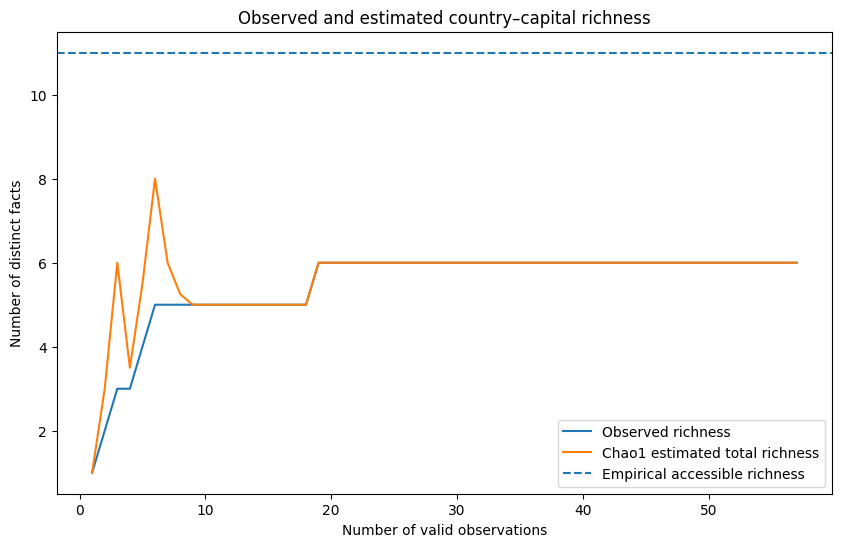

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    trajectory_df["observation_index"],
    trajectory_df["S_obs"],
    label="Observed richness",
)

plt.plot(
    trajectory_df["observation_index"],
    trajectory_df["Chao1"],
    label="Chao1 estimated total richness",
)

plt.axhline(
    S_ACCESSIBLE,
    linestyle="--",
    label="Empirical accessible richness",
)

plt.xlabel("Number of valid observations")
plt.ylabel("Number of distinct facts")
plt.title(
    "Observed and estimated country–capital richness"
)
plt.legend()
plt.show()

# Step 24 — Read the plot correctly

The plot may behave irregularly because the sample is very small.

What to look for:

1. **Observed richness** can only stay constant or increase.
2. **Chao1** may move up or down because \(f_1\) and \(f_2\) change.
3. A singleton becomes a doubleton when observed again.
4. That change can reduce the estimated unseen tail.
5. If obscure countries are almost never selected, Chao1 may underestimate the accessible set.

This is not necessarily a coding error. It reveals that fact-detection probabilities are highly unequal.

# Step 25 — A tiny calculation without an LLM

Run this cell if the actual model results are confusing.

We manually create this frequency distribution:

```text
France–Paris        5
Japan–Tokyo         4
Canada–Ottawa       2
Estonia–Tallinn     1
Palau–Ngerulmud     1
Suriname–Paramaribo 1
```

Therefore:

- \(n = 14\);
- \(S_{\text{obs}} = 6\);
- \(f_1 = 3\);
- \(f_2 = 1\).

Then:

$
\widehat S_{\text{unseen}}
=
\frac{3(3-1)}
{2(1+1)}
=
\frac{6}{4}
=
1.5
$

and:

$
\widehat S_{\text{Chao1}}
=
6+1.5
=
7.5.
$

In [28]:
manual_example_counts = Counter(
    {
        ("France", "Paris"): 5,
        ("Japan", "Tokyo"): 4,
        ("Canada", "Ottawa"): 2,
        ("Estonia", "Tallinn"): 1,
        ("Palau", "Ngerulmud"): 1,
        ("Suriname", "Paramaribo"): 1,
    }
)

manual_n = sum(
    manual_example_counts.values()
)

manual_S_obs = len(
    manual_example_counts
)

manual_f1 = sum(
    count == 1
    for count in manual_example_counts.values()
)

manual_f2 = sum(
    count == 2
    for count in manual_example_counts.values()
)

manual_unseen = (
    manual_f1
    * (manual_f1 - 1)
    / (
        2
        * (manual_f2 + 1)
    )
)

manual_chao1 = (
    manual_S_obs
    + manual_unseen
)

manual_good_turing = (
    manual_f1
    / manual_n
)

print("MANUAL EXAMPLE")
print("==============")

print("\nFrequency table:")
for fact, frequency in manual_example_counts.items():
    print(f"{fact}: {frequency}")

print("\nn =", manual_n)
print("S_obs =", manual_S_obs)
print("f1 =", manual_f1)
print("f2 =", manual_f2)

print("\nChao1 unseen calculation:")
print(
    f"[{manual_f1} × ({manual_f1} - 1)] / "
    f"[2 × ({manual_f2} + 1)]"
)
print(
    "=",
    manual_unseen,
)

print("\nChao1 total richness:")
print(
    f"{manual_S_obs} + {manual_unseen}"
)
print(
    "=",
    manual_chao1,
)

print("\nGood–Turing:")
print(
    f"{manual_f1} / {manual_n}"
)
print(
    "=",
    round(manual_good_turing, 4),
)
print(
    "=",
    round(100 * manual_good_turing, 2),
    "%",
)

MANUAL EXAMPLE

Frequency table:
('France', 'Paris'): 5
('Japan', 'Tokyo'): 4
('Canada', 'Ottawa'): 2
('Estonia', 'Tallinn'): 1
('Palau', 'Ngerulmud'): 1
('Suriname', 'Paramaribo'): 1

n = 14
S_obs = 6
f1 = 3
f2 = 1

Chao1 unseen calculation:
[3 × (3 - 1)] / [2 × (1 + 1)]
= 1.5

Chao1 total richness:
6 + 1.5
= 7.5

Good–Turing:
3 / 14
= 0.2143
= 21.43 %


# Final conceptual summary

The calculation follows this exact chain:

```text
Repeated LLM inference
        ↓
Keep only correct facts
        ↓
Canonicalize each fact
        ↓
Count how often every fact appears
        ↓
Calculate n, S_obs, f1, and f2
        ↓
Apply Chao1
        ↓
Estimate unseen richness
        ↓
Apply Good–Turing
        ↓
Estimate probability that the next valid fact is new
```

The most important distinction is:

```text
Reference universe
≠
Accessible knowledge
≠
Observed knowledge
≠
Estimated total knowledge
```

For this toy experiment:

- the **reference universe** is the 12-pair table;
- **accessible knowledge** is what direct probing can elicit;
- **observed knowledge** is what appears in limited free-choice samples;
- **estimated total knowledge** is calculated from the observed frequency distribution.

The estimate is always tied to the exact sampling protocol.